## Сравнение моделей

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
xgb_results = [
    {
        "target": "room_size_norm",
        "mae": 0.149312,
        "rmse": 0.192495,
        "r2": 0.549438
    },
    {
        "target": "wet_level_norm",
        "mae": 0.147748,
        "rmse": 0.187519,
        "r2": 0.605318
    },
    {
        "target": "rate_hz_norm",
        "mae": 0.125446,
        "rmse": 0.168256,
        "r2": 0.663378
    },
    {
        "target": "depth_norm",
        "mae": 0.107887,
        "rmse": 0.140851,
        "r2": 0.759625
    }
]

xgb_metrics_df = pd.DataFrame(xgb_results)

xgb_metrics_df

,target,mae,rmse,r2
0,room_size_norm,0.149312,0.192495,0.549438
1,wet_level_norm,0.147748,0.187519,0.605318
2,rate_hz_norm,0.125446,0.168256,0.663378
3,depth_norm,0.107887,0.140851,0.759625


In [3]:
cnn_results = [
    {
        "target": "room_size_norm",
        "mae": 0.113531,
        "rmse": 0.151843,
        "r2": 0.719649
    },
    {
        "target": "wet_level_norm",
        "mae": 0.090672,
        "rmse": 0.118700,
        "r2": 0.841854
    },
    {
        "target": "rate_hz_norm",
        "mae": 0.099963,
        "rmse": 0.143456,
        "r2": 0.755295
    },
    {
        "target": "depth_norm",
        "mae": 0.070869,
        "rmse": 0.094120,
        "r2": 0.892668
    }
]

cnn_metrics_df = pd.DataFrame(cnn_results)

cnn_metrics_df

,target,mae,rmse,r2
0,room_size_norm,0.113531,0.151843,0.719649
1,wet_level_norm,0.090672,0.118700,0.841854
2,rate_hz_norm,0.099963,0.143456,0.755295
3,depth_norm,0.070869,0.094120,0.892668


In [4]:
results_df = pd.merge(
    xgb_metrics_df,
    cnn_metrics_df,
    on="target",
    suffixes=("_xgb", "_cnn")
)

results_df

,target,mae_xgb,rmse_xgb,r2_xgb,mae_cnn,rmse_cnn,r2_cnn
0,room_size_norm,0.149312,0.192495,0.549438,0.113531,0.151843,0.719649
1,wet_level_norm,0.147748,0.187519,0.605318,0.090672,0.118700,0.841854
2,rate_hz_norm,0.125446,0.168256,0.663378,0.099963,0.143456,0.755295
3,depth_norm,0.107887,0.140851,0.759625,0.070869,0.094120,0.892668


In [5]:
results_df["r2_gain"] = results_df["r2_cnn"] - results_df["r2_xgb"]

results_df["mae_reduction_pct"] = (results_df["mae_xgb"] - results_df["mae_cnn"]) * 100 / results_df["mae_xgb"]

results_df

,target,mae_xgb,rmse_xgb,r2_xgb,mae_cnn,rmse_cnn,r2_cnn,r2_gain,mae_reduction_pct
0,room_size_norm,0.149312,0.192495,0.549438,0.113531,0.151843,0.719649,0.170211,23.963914
1,wet_level_norm,0.147748,0.187519,0.605318,0.090672,0.118700,0.841854,0.236536,38.630641
2,rate_hz_norm,0.125446,0.168256,0.663378,0.099963,0.143456,0.755295,0.091917,20.313920
3,depth_norm,0.107887,0.140851,0.759625,0.070869,0.094120,0.892668,0.133043,34.311826


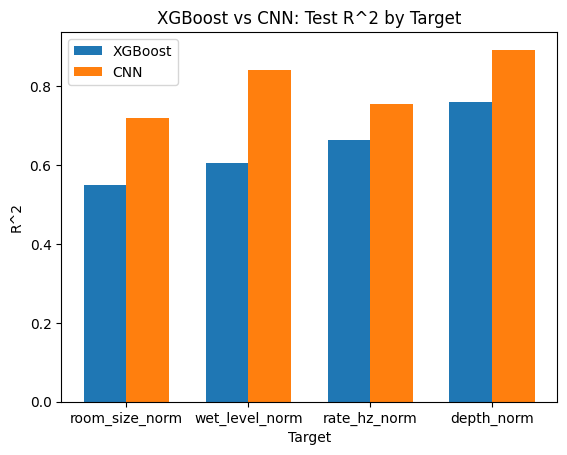

In [8]:
x = np.arange(len(results_df))
width = 0.35

plt.bar(
    x - width / 2,
    results_df["r2_xgb"],
    width=width,
    label="XGBoost"
)

plt.bar(
    x + width / 2,
    results_df["r2_cnn"],
    width=width,
    label="CNN"
)

plt.xticks(
    x,
    results_df["target"]
)

plt.xlabel("Target")
plt.ylabel("R^2")
plt.title("XGBoost vs CNN: Test R^2 by Target")

plt.legend()

plt.show()

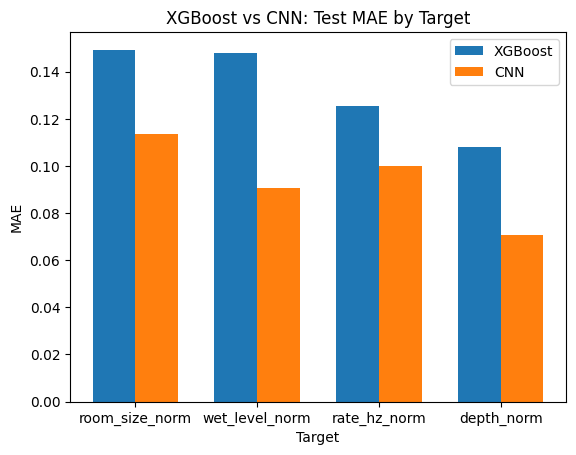

In [9]:
x = np.arange(len(results_df))
width = 0.35

plt.bar(
    x - width / 2,
    results_df["mae_xgb"],
    width=width,
    label="XGBoost"
)

plt.bar(
    x + width / 2,
    results_df["mae_cnn"],
    width=width,
    label="CNN"
)

plt.xticks(
    x,
    results_df["target"]
)

plt.xlabel("Target")
plt.ylabel("MAE")
plt.title("XGBoost vs CNN: Test MAE by Target")

plt.legend()

plt.show()

In [10]:
xgb_mean_mae = xgb_metrics_df["mae"].mean()
xgb_mean_rmse = xgb_metrics_df["rmse"].mean()
xgb_mean_r2 = xgb_metrics_df["r2"].mean()

cnn_mean_mae = cnn_metrics_df["mae"].mean()
cnn_mean_rmse = cnn_metrics_df["rmse"].mean()
cnn_mean_r2 = cnn_metrics_df["r2"].mean()

summary_results = [
    {
        "model": "XGBoost",
        "mean_mae": xgb_mean_mae,
        "mean_rmse": xgb_mean_rmse,
        "mean_r2": xgb_mean_r2
    },
    {
        "model": "CNN",
        "mean_mae": cnn_mean_mae,
        "mean_rmse": cnn_mean_rmse,
        "mean_r2": cnn_mean_r2
    }
]

summary_df = pd.DataFrame(summary_results)

summary_df

,model,mean_mae,mean_rmse,mean_r2
0,XGBoost,0.132598,0.17228,0.644440
1,CNN,0.093759,0.12703,0.802367


In [13]:
mae_reduction_pct = (xgb_mean_mae - cnn_mean_mae) * 100 / xgb_mean_mae
r2_gain = cnn_mean_r2 - xgb_mean_r2

print(f"MAE reduction = {mae_reduction_pct}%")
print(f"R^2 gain = {r2_gain}")

MAE reduction = 29.291110553872308%
R^2 gain = 0.15792675000000012


## Conclusion

CNN на Mel-spectrogram заметно превзошла XGBoost на engineered features:

| Model   |   Mean MAE |    Mean R² |
| ------- | ---------: | ---------: |
| XGBoost |     0.1326 |     0.6444 |
| CNN     | **0.0938** | **0.8024** |

CNN снизила MAE примерно на **29%** и показала лучший R² по всем четырём параметрам. Особенно сильный результат получен для `depth_norm` и `wet_level_norm`.

Итоговая CNN была выбрана по validation с early stopping и один раз оценена на независимом test split.
